# Step 5: Hybrid PD Model — Baseline vs NLP-augmented Variants

Train 6 PD model variants on the same train/test split:

| Variant | Features |
|---|---|
| M0 baseline | structured (WoE-binned) only |
| M1 +tfidf | structured + tfidf_features (5000-dim sparse) |
| M2 +w2v | structured + w2v_features (50-dim dense) |
| M3 +cnn | structured + cnn_score (1-dim, distilled from CNN) |
| M4 +categorical | structured + title_ohe + emp_ohe + desc_missing |
| M5 full | structured + all NLP features above |

Evaluate via AUC, Gini, KS, Lift; compute EL = PD × LGD × EAD using teammate's Beta-GLM (LGD) and LinearRegression (EAD).

## Section 1 — Setup & Load

In [1]:
import sys, os
sys.path.insert(0, '/home/jovyan/work/src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pyspark.sql import SparkSession, functions as F
from pyspark.sql.types import DoubleType
from pyspark.ml.feature import VectorAssembler, VectorSizeHint
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.ml import Pipeline, PipelineModel
from pyspark.ml.linalg import Vectors, VectorUDT, SparseVector

from evaluation import (compute_auc_roc, compute_gini, compute_ks_statistic,
                        compute_lift_table, plot_lift_chart)


In [2]:
spark = (SparkSession.builder
    .appName("MF810_HybridPD")
    .master("local[*]")
    .config("spark.driver.memory", "8g")
    .config("spark.driver.maxResultSize", "2g")
    .config("spark.sql.shuffle.partitions", "32")
    .config("spark.sql.autoBroadcastJoinThreshold", "-1")
    .config("spark.sql.adaptive.autoBroadcastJoinThreshold", "-1")
    .config("spark.sql.parquet.compression.codec", "snappy")
    .config("spark.memory.fraction", "0.6")
    .config("spark.memory.offHeap.enabled", "true")
    .config("spark.memory.offHeap.size", "2g")
    .getOrCreate())
# Enforce no-broadcast even if SparkSession gets reused
spark.conf.set("spark.sql.autoBroadcastJoinThreshold", "-1")
spark.conf.set("spark.sql.adaptive.autoBroadcastJoinThreshold", "-1")


In [3]:
# ============================================================
# Helpers — defined once, reused by Phase A (subset) and Phase B (full)
# ============================================================
import os
from pyspark.sql.types import StructType, StructField

# Paths for the skinny NLP checkpoints (written in Section 2)
NLP_TRAIN_CKPT = "/home/jovyan/work/data/parquet/_hybrid_nlp_train.parquet"
NLP_TEST_CKPT  = "/home/jovyan/work/data/parquet/_hybrid_nlp_test.parquet"

# Known fixed-dim NLP vector columns (tfidf/w2v).
# title_ohe / emp_ohe widths are inferred at call time via infer_vector_size().
VECTOR_COL_SIZES = {"tfidf_features": 5000, "w2v_features": 50}
VECTOR_COLS = {"tfidf_features", "w2v_features", "title_ohe", "emp_ohe"}

# Class 0 (default) is the positive class for prob_default, since the output: probability [P(class=0), P(class=1)]
extract_p_default = F.udf(lambda v: float(v[0]), DoubleType())


# ---------- Skinny NLP frame builder ----------
def prepare_nlp(struct, nlp, tfidf, w2v, spark):
    """Skinny NLP frame: id, good_bad + 7 NLP cols (vectors zero-filled).

    tfidf/w2v cover only ~6% of rows (where desc is non-null). LEFT JOIN +
    zero-fill so VectorAssembler always sees a vector. tfidf/w2v are small
    (~16 MB each) and joined without broadcast hints to avoid driver OOM.
    """
    zero_sparse = SparseVector(5000, [], [])
    zero_dense  = Vectors.dense([0.0] * 50)
    zeros_df = spark.createDataFrame(
        [(zero_sparse, zero_dense)],
        schema=StructType([
            StructField("zero_tfidf", VectorUDT()),
            StructField("zero_w2v",   VectorUDT()),
        ]),
    )
    return (struct.select("id", "good_bad")
            .join(nlp.drop("good_bad"),   on="id", how="left")
            .join(tfidf,                  on="id", how="left")
            .join(w2v,                    on="id", how="left")
            .crossJoin(F.broadcast(zeros_df))
            .withColumn("tfidf_features",
                F.when(F.col("tfidf_features").isNull(), F.col("zero_tfidf"))
                 .otherwise(F.col("tfidf_features")))
            .withColumn("w2v_features",
                F.when(F.col("w2v_features").isNull(), F.col("zero_w2v"))
                 .otherwise(F.col("w2v_features")))
            .drop("zero_tfidf", "zero_w2v")
            .fillna({"cnn_score": 0.0, "desc_missing": 1, "emp_cluster": 0}))


# ---------- Vector size inference (fixes the cell-27 bug) ----------
def infer_vector_size(col_name, ckpt_path=NLP_TRAIN_CKPT):
    if col_name in VECTOR_COL_SIZES:
        return VECTOR_COL_SIZES[col_name]
    v = (spark.read.parquet(ckpt_path)
         .select(col_name).filter(F.col(col_name).isNotNull()).first())
    return v[col_name].size


# ---------- Build train/test frames per variant ----------
def build_fit_data(train_struct, test_struct, baseline_cols, nlp_cols,
                   nlp_train_path=NLP_TRAIN_CKPT, nlp_test_path=NLP_TEST_CKPT):
    """Inner-join structured baseline with only the NLP cols this variant uses.

    Avoids shuffling unused vector cols. M0 (no nlp_cols) returns the structured
    frame untouched.
    """
    train_base = train_struct.select("id", "good_bad", *baseline_cols)
    test_base  = test_struct.select("id", "good_bad", *baseline_cols)
    if not nlp_cols:
        return train_base, test_base
    nlp_train = spark.read.parquet(nlp_train_path).select("id", *nlp_cols)
    nlp_test  = spark.read.parquet(nlp_test_path).select("id", *nlp_cols)
    return (train_base.join(nlp_train, on="id", how="inner"),
            test_base.join(nlp_test,  on="id", how="inner"))


# ---------- Train one PD variant ----------
def train_pd_variant(name, train_struct, test_struct, baseline_cols, nlp_cols,
                     evaluator, max_iter=50, reg_param=0.01,
                     nlp_train_path=NLP_TRAIN_CKPT, nlp_test_path=NLP_TEST_CKPT):
    feat_cols = baseline_cols + nlp_cols
    print(f"\n── Training {name}: baseline({len(baseline_cols)}) + nlp({len(nlp_cols)}) = {len(feat_cols)} ──")

    fit_train, fit_test = build_fit_data(train_struct, test_struct,
                                         baseline_cols, nlp_cols,
                                         nlp_train_path, nlp_test_path)

    pre_stages = []
    for c in nlp_cols:
        if c in VECTOR_COLS:
            size = infer_vector_size(c, nlp_train_path)
            pre_stages.append(VectorSizeHint(inputCol=c, size=size, handleInvalid="skip"))
            print(f"   VectorSizeHint: {c} = {size}")

    assembler = VectorAssembler(inputCols=feat_cols, outputCol="features",
                                handleInvalid="skip")
    lr = LogisticRegression(featuresCol="features", labelCol="good_bad",
                            maxIter=max_iter, regParam=reg_param, elasticNetParam=0.0)
    model = Pipeline(stages=pre_stages + [assembler, lr]).fit(fit_train)
    preds = model.transform(fit_test)

    auc = evaluator.evaluate(preds)
    pdf = preds.select(
        "id",
        F.col("good_bad").alias("y_true"),
        extract_p_default("probability").alias("prob_default"),
    ).toPandas()

    spark.catalog.clearCache()

    print(f"   AUC={auc:.4f}, Gini={2*auc-1:.4f}")
    return {
        "metrics":     {"auc": auc, "gini": 2*auc - 1, "n_features": len(feat_cols)},
        "predictions": pdf,
        "model":       model,
    }


# ---------- Reporting helpers ----------
def compute_metrics_table(results, predictions, baseline_name, ks_fn):
    """Build comparison DataFrame: AUC / Gini / KS / delta_auc_vs_baseline."""
    df = pd.DataFrame(results).T
    df["delta_auc_vs_baseline"] = df["auc"] - df.loc[baseline_name, "auc"]
    for name, pdf in predictions.items():
        y_default = (pdf["y_true"] == 0).astype(int)
        ks, _ = ks_fn(y_default, pdf["prob_default"])
        df.loc[name, "ks"] = ks
    return df


def plot_roc_overlay(predictions, results, title, out_path):
    from sklearn.metrics import roc_curve
    fig, ax = plt.subplots(figsize=(8, 7))
    for name, pdf in predictions.items():
        y_default = (pdf["y_true"] == 0).astype(int)
        fpr, tpr, _ = roc_curve(y_default, pdf["prob_default"])
        ax.plot(fpr, tpr, label=f"{name} (AUC={results[name]['auc']:.4f})")
    ax.plot([0,1], [0,1], "k--", alpha=0.3)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title(title)
    ax.legend(loc="lower right")
    plt.tight_layout()
    os.makedirs(os.path.dirname(out_path), exist_ok=True)
    plt.savefig(out_path, dpi=120)
    plt.show()


def plot_lift_comparison(predictions, name_a, name_b, lift_fn, title, out_path):
    y_a = (predictions[name_a]["y_true"] == 0).astype(int)
    y_b = (predictions[name_b]["y_true"] == 0).astype(int)
    lift_a = lift_fn(y_a, predictions[name_a]["prob_default"], n_deciles=10)
    lift_b = lift_fn(y_b, predictions[name_b]["prob_default"], n_deciles=10)

    fig, ax = plt.subplots(figsize=(10, 5))
    x = np.arange(len(lift_a))
    ax.bar(x - 0.2, lift_a["lift"], width=0.4, label=name_a, color="steelblue")
    ax.bar(x + 0.2, lift_b["lift"], width=0.4, label=name_b, color="crimson")
    ax.axhline(y=1, color="black", linestyle="--", alpha=0.5, label="Random (lift=1)")
    ax.set_xticks(x)
    ax.set_xticklabels(lift_a["decile"])
    ax.set_xlabel("Decile (1 = highest predicted risk)")
    ax.set_ylabel("Lift")
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    os.makedirs(os.path.dirname(out_path), exist_ok=True)
    plt.savefig(out_path, dpi=120)
    plt.show()
    print(f"{name_a} top-decile lift: {lift_a.iloc[0]['lift']:.4f}")
    print(f"{name_b} top-decile lift: {lift_b.iloc[0]['lift']:.4f}")
    return lift_a, lift_b


def extract_feature_names_for_pipeline(pipeline_model, structured_cols, nlp_cols,
                                       ckpt_path=NLP_TRAIN_CKPT):
    """Build feature-name list matching the assembled vector order.

    Order = structured_cols (each scalar) followed by each nlp_col expanded
    by its vector width (1 for scalars).
    """
    names = list(structured_cols)
    for c in nlp_cols:
        if c in VECTOR_COL_SIZES:
            names += [f"{c}_{i}" for i in range(VECTOR_COL_SIZES[c])]
        elif c in VECTOR_COLS:  # title_ohe / emp_ohe
            size = infer_vector_size(c, ckpt_path)
            names += [f"{c}_{i}" for i in range(size)]
        else:
            names.append(c)  # scalar (cnn_score, desc_missing, emp_cluster)
    return names


def plot_feature_importance(pipeline_model, feat_names, top_k, title, out_path,
                            nlp_prefixes=("tfidf_features_", "w2v_features_",
                                          "cnn_score", "title_ohe_", "emp_ohe_",
                                          "desc_missing", "emp_cluster")):
    lr_stage = pipeline_model.stages[-1]
    coefs = lr_stage.coefficients.toArray()
    assert len(feat_names) == len(coefs), (
        f"Name mismatch: {len(feat_names)} names vs {len(coefs)} coefs")

    df = pd.DataFrame({"feature": feat_names, "coefficient": coefs})
    df["abs_coef"] = df["coefficient"].abs()
    df["source"] = df["feature"].apply(
        lambda n: "NLP" if any(n.startswith(p) or n == p for p in nlp_prefixes)
                  else "structured")
    top = df.sort_values("abs_coef", ascending=False).head(top_k)
    print(f"Top {top_k} features by |coefficient|:")
    print(top[["feature", "coefficient", "source"]].to_string(index=False))
    print(f"\nNLP features in top {top_k}: {(top['source']=='NLP').sum()} / {top_k}")

    fig, ax = plt.subplots(figsize=(9, max(6, top_k * 0.3)))
    top_sorted = top.sort_values("coefficient")
    colors = top_sorted["source"].map({"NLP": "crimson", "structured": "steelblue"})
    ax.barh(top_sorted["feature"], top_sorted["coefficient"], color=colors,
            edgecolor="black")
    ax.axvline(0, color="black", lw=0.5)
    ax.set_xlabel("Coefficient")
    ax.set_title(title)
    plt.tight_layout()
    os.makedirs(os.path.dirname(out_path), exist_ok=True)
    plt.savefig(out_path, dpi=120)
    plt.show()
    return df


def compute_el_table(predictions, baseline_name, hybrid_name, lgd_pdf, ead_pdf,
                     out_path):
    """Per-loan EL = PD × LGD × EAD for baseline and hybrid PD models."""
    el = (predictions[baseline_name]
          .rename(columns={"prob_default": "PD_baseline"})[["id", "y_true", "PD_baseline"]]
          .merge(predictions[hybrid_name]
                 .rename(columns={"prob_default": "PD_hybrid"})[["id", "PD_hybrid"]],
                 on="id")
          .merge(lgd_pdf[["id", "lgd_pred"]], on="id")
          .merge(ead_pdf[["id", "ead_pred"]], on="id"))
    el["EL_baseline"] = el["PD_baseline"] * el["lgd_pred"] * el["ead_pred"]
    el["EL_hybrid"]   = el["PD_hybrid"]   * el["lgd_pred"] * el["ead_pred"]
    el["EL_delta"]    = el["EL_hybrid"] - el["EL_baseline"]

    print(f"=== EL summary ({baseline_name} vs {hybrid_name}) ===")
    print(f"Loans: {len(el):,}")
    print(f"Total EL — baseline: ${el['EL_baseline'].sum():,.2f}")
    print(f"Total EL — hybrid:   ${el['EL_hybrid'].sum():,.2f}")
    print(f"Mean EL/loan — baseline: ${el['EL_baseline'].mean():.2f}")
    print(f"Mean EL/loan — hybrid:   ${el['EL_hybrid'].mean():.2f}")
    print(f"Mean delta: ${el['EL_delta'].mean():.2f}")

    os.makedirs(os.path.dirname(out_path), exist_ok=True)
    el.to_csv(out_path, index=False)
    print(f"\nSaved {out_path}")
    return el


print("Helpers loaded:")
print("  prepare_nlp, build_fit_data, train_pd_variant, infer_vector_size")
print("  compute_metrics_table, plot_roc_overlay, plot_lift_comparison")
print("  extract_feature_names_for_pipeline, plot_feature_importance, compute_el_table")


Helpers loaded:
  prepare_nlp, build_fit_data, train_pd_variant, infer_vector_size
  compute_metrics_table, plot_roc_overlay, plot_lift_comparison
  extract_feature_names_for_pipeline, plot_feature_importance, compute_el_table


In [4]:
# Structured features (teammate)
struct_train = spark.read.parquet("/home/jovyan/work/data/parquet/features_pd_train.parquet")
struct_test  = spark.read.parquet("/home/jovyan/work/data/parquet/features_pd_test.parquet")

# NLP features
nlp_feat_train = spark.read.parquet("/home/jovyan/work/outputs/nlp_features_train.parquet")
nlp_feat_test  = spark.read.parquet("/home/jovyan/work/outputs/nlp_features_test.parquet")
tfidf_train    = spark.read.parquet("/home/jovyan/work/outputs/nlp_tfidf_train.parquet")
tfidf_test     = spark.read.parquet("/home/jovyan/work/outputs/nlp_tfidf_test.parquet")
w2v_train      = spark.read.parquet("/home/jovyan/work/outputs/nlp_w2v_train.parquet")
w2v_test       = spark.read.parquet("/home/jovyan/work/outputs/nlp_w2v_test.parquet")

assert set(struct_train.columns) == set(struct_test.columns), "train/test schema drift"
print(f"struct_train: {struct_train.count()} rows × {len(struct_train.columns)} cols")
print(f"struct_test:  {struct_test.count()} rows × {len(struct_test.columns)} cols")


struct_train: 1807770 rows × 136 cols
struct_test:  452931 rows × 136 cols


## Section 2 — Join + Fill Missing NLP Features

94% of borrowers don't have `desc`, so `tfidf_features` and `w2v_features` will be NULL after LEFT JOIN. Fill with zero vectors so VectorAssembler works.

In [5]:
# Define structured_cols from train (train/test schemas already aligned, see Section 1 assert).
# Restrict to int (= WoE-binned indicators), exclude ids/labels/targets/raw redundant cols.
EXCLUDE = {
    "id", "member_id",
    "good_bad", "default_flag",          # labels
    "lgd", "ccf", "ead",                 # targets
    "emp_length_int", "term_int",        # raw, redundant w/ binned versions
    "mths_since_earliest_cr_line", "mths_since_issue_d",
}
structured_cols = [c for c, dt in struct_train.dtypes
                   if c not in EXCLUDE and dt == "int"]
print(f"structured_cols: {len(structured_cols)}")
print(f"  first 5: {structured_cols[:5]}")
print(f"  last 5:  {structured_cols[-5:]}")

structured_cols: 134
  first 5: ['grade_B', 'grade_A|MISSING', 'grade_D', 'grade_F|G|E', 'grade_C']
  last 5:  ['mths_since_last_delinq_(19,34]', 'mths_since_last_delinq_(34,49]', 'mths_since_last_record_(-inf,69]', 'mths_since_last_record_(69,inf]', 'mths_since_last_record_MISSING']


In [6]:
# --- Feature selection: pick top 60 structured cols by default-rate differential ---
# For binary indicator col c: |P(c=1 | default) - P(c=1 | non_default)|
# = how much this bin moves between default/non-default borrowers.
# Simplified IV proxy — one Spark pass, no vector assembly, tiny result.
#
# Why: large structured col set × 1.8M rows can OOM the cached LR matrix.
# Capping at 60 keeps cached features inside the driver heap budget.

means = (struct_train
         .groupBy("good_bad")
         .agg(*[F.avg(F.col(c)).alias(c) for c in structured_cols])
         .collect())
means_by_label = {r["good_bad"]: r.asDict() for r in means}

scores = {c: abs(means_by_label[0][c] - means_by_label[1][c])
          for c in structured_cols}
top_k = min(60, len(structured_cols))
top_cols = sorted(scores, key=scores.get, reverse=True)[:top_k]

print(f"Picked top {top_k} out of {len(structured_cols)} structured cols")
print("\nTop 10 by |default-rate diff|:")
for c in top_cols[:10]:
    print(f"  {scores[c]:.4f}  {c}")

structured_cols = top_cols  # overwrite — rest of notebook uses this smaller list


Picked top 60 out of 134 structured cols

Top 10 by |default-rate diff|:
  0.1937  mths_since_issue_d_(32,MISSING]
  0.1882  mths_since_issue_d_(-inf,12]
  0.1589  grade_A|MISSING
  0.1347  grade_F|G|E
  0.1207  term_int_(36,60]
  0.1207  term_int_(60,MISSING]
  0.1187  verification_status_NotVerified|MISSING
  0.1095  int_rate_(16_99,20_99]
  0.1094  grade_B
  0.1087  inq_last_6mths_(0,1]


In [7]:
# --- Write SKINNY train NLP checkpoint ---
# repartition(40) → only 40 output files. With 4 cores, ≤4 writer tasks run at
# once; lower partition count = lower per-task overhead.
(prepare_nlp(struct_train, nlp_feat_train, tfidf_train, w2v_train, spark)
    .repartition(40, "id")
    .write.mode("overwrite").parquet(NLP_TRAIN_CKPT))
spark.catalog.clearCache()
print("Wrote SKINNY NLP train checkpoint to", NLP_TRAIN_CKPT)


Wrote SKINNY NLP train checkpoint to /home/jovyan/work/data/parquet/_hybrid_nlp_train.parquet


In [8]:
# --- Write SKINNY test NLP checkpoint ---
(prepare_nlp(struct_test, nlp_feat_test, tfidf_test, w2v_test, spark)
    .repartition(10, "id")
    .write.mode("overwrite").parquet(NLP_TEST_CKPT))
spark.catalog.clearCache()
print("Wrote SKINNY NLP test checkpoint to", NLP_TEST_CKPT)


Wrote SKINNY NLP test checkpoint to /home/jovyan/work/data/parquet/_hybrid_nlp_test.parquet


In [9]:
nlp_train_check = spark.read.parquet(NLP_TRAIN_CKPT)
nlp_test_check  = spark.read.parquet(NLP_TEST_CKPT)

print(f"struct_train: {struct_train.count():,} rows")
print(f"struct_test:  {struct_test.count():,} rows")
print(f"NLP train ckpt: {nlp_train_check.count():,} rows × {len(nlp_train_check.columns)} cols")
print(f"NLP test ckpt:  {nlp_test_check.count():,} rows × {len(nlp_test_check.columns)} cols")
print(f"NLP cols: {nlp_train_check.columns}\n")


struct_train: 1,807,770 rows
struct_test:  452,931 rows
NLP train ckpt: 1,807,770 rows × 9 cols
NLP test ckpt:  452,931 rows × 9 cols
NLP cols: ['id', 'good_bad', 'desc_missing', 'title_ohe', 'emp_ohe', 'emp_cluster', 'cnn_score', 'tfidf_features', 'w2v_features']



In [10]:
nlp_train_check.show(5)

+---------+--------+------------+--------------+--------------+-----------+---------+--------------+--------------------+
|       id|good_bad|desc_missing|     title_ohe|       emp_ohe|emp_cluster|cnn_score|tfidf_features|        w2v_features|
+---------+--------+------------+--------------+--------------+-----------+---------+--------------+--------------------+
|100001365|       1|           1|(20,[0],[1.0])|(19,[0],[1.0])|          0|      0.0|  (5000,[],[])|[0.0,0.0,0.0,0.0,...|
|100001844|       0|           1|(20,[0],[1.0])|(19,[0],[1.0])|          0|      0.0|  (5000,[],[])|[0.0,0.0,0.0,0.0,...|
|100007398|       1|           1|(20,[1],[1.0])|(19,[0],[1.0])|          0|      0.0|  (5000,[],[])|[0.0,0.0,0.0,0.0,...|
|100007452|       1|           1|(20,[4],[1.0])|(19,[0],[1.0])|          0|      0.0|  (5000,[],[])|[0.0,0.0,0.0,0.0,...|
|100015985|       1|           1|(20,[0],[1.0])|(19,[8],[1.0])|          8|      0.0|  (5000,[],[])|[0.0,0.0,0.0,0.0,...|
+---------+--------+----

## Section 2.5 — Build desc-present subset (Phase A)

`desc` is missing in ~94% of rows, so on the full data tfidf/w2v/cnn are zero-filled for most borrowers — their NLP signal gets diluted to ~0.

Phase A: take only rows where `desc_missing == 0` (across train + test combined) and **re-split 80/20** with `seed=42`. This gives a clean apples-to-apples comparison of NLP value when text is actually available.

Phase B (next sections) keeps the original full-data split.


In [11]:
# Build desc-present subset: union train+test ids where desc was non-null,
# then re-split 80/20.
nlp_train = spark.read.parquet(NLP_TRAIN_CKPT)
nlp_test  = spark.read.parquet(NLP_TEST_CKPT)

#find id which has desc 
desc_ids = (nlp_train
            .filter(F.col("desc_missing") == 0)
            .select("id")
            .union(nlp_test
                   .filter(F.col("desc_missing") == 0)
                   .select("id"))
            .distinct())
n_desc = desc_ids.count()
print(f"desc-present total: {n_desc:,} rows")

# Combine struct_train + struct_test, then filter to desc-present ids.
# allowMissingColumns=True is defensive — Section 1 assert already guards schema alignment.
struct_all  = struct_train.unionByName(struct_test, allowMissingColumns=True)
struct_desc = struct_all.join(desc_ids, "id", "inner")

# Independent 80/20 split, fixed seed for reproducibility.
struct_train_sub, struct_test_sub = struct_desc.randomSplit([0.8, 0.2], seed=42)
struct_train_sub = struct_train_sub.cache()
struct_test_sub  = struct_test_sub.cache()

n_tr, n_te = struct_train_sub.count(), struct_test_sub.count()
n_def_tr = struct_train_sub.filter(F.col("good_bad") == 0).count()
print(f"subset train: {n_tr:,} rows, test: {n_te:,} rows")
print(f"subset train default rate: {n_def_tr / n_tr:.4f}")


desc-present total: 125,814 rows
subset train: 100,675 rows, test: 25,139 rows
subset train default rate: 0.1561


In [12]:
struct_train_sub.show()

+--------+--------+-------+---------------+-------+-----------+-------+------------------------------+-----------------------------------+------------------+----------------------+----------------------------+-------------------------------------+----------------+----------------+----------------------------+-------------------------------+----------------------------+---------------------------------------------+----------------------------------+---------------------------------------+----------------------------+-----------------------------------------------------------+-------------------------------+------------------------+-----------------------------------------------------------------------------+-----------------------------+---------------------+----------------+---------------------+-----------------------+--------------------+--------------------+--------------------+---------------------+-----------------+-------------------+--------------------+----------------------+--

## Section 3 — Define Variant Feature Sets

Two phases:

**Phase A** (desc-present subset, ~108K train / ~27K test) — full 6-variant comparison to demonstrate NLP value when text is available.

| Variant | NLP add-on |
|---|---|
| M0_baseline | — |
| M1_+tfidf | tfidf_features |
| M2_+w2v | w2v_features |
| M3_+cnn | cnn_score |
| M4_+categorical | title_ohe + emp_ohe |
| M5_full | tfidf + w2v + cnn + title_ohe + emp_ohe |

`desc_missing` is excluded — it's a constant 0 within the subset.

**Phase B** (full data, 1.8M / 451K) — only baseline + categorical, since tfidf/w2v/cnn are zero-filled for 94% of rows on full data.

| Variant | NLP add-on |
|---|---|
| M0_baseline_full | — |
| M_categorical_full | title_ohe + emp_ohe |


In [13]:
# Phase A: 6 variants on desc-present subset
variants_subset = {
    "M0_baseline":     [],
    "M1_+tfidf":       ["tfidf_features"],
    "M2_+w2v":         ["w2v_features"],
    "M3_+cnn":         ["cnn_score"],
    "M4_+categorical": ["title_ohe", "emp_ohe"],
    "M5_full":         ["tfidf_features", "w2v_features", "cnn_score",
                        "title_ohe", "emp_ohe"],
}

# Phase B: 2 variants on full data — no tfidf/w2v/cnn (mostly zero-filled),
# no desc_missing (per design decision).
variants_full = {
    "M0_baseline_full":   [],
    "M_categorical_full": ["title_ohe", "emp_ohe"],
}

print("=== Phase A (subset) ===")
for k, v in variants_subset.items():
    print(f"  {k}: structured({len(structured_cols)}) + nlp({len(v)}) = {len(structured_cols)+len(v)}")

print("\n=== Phase B (full) ===")
for k, v in variants_full.items():
    print(f"  {k}: structured({len(structured_cols)}) + nlp({len(v)}) = {len(structured_cols)+len(v)}")


=== Phase A (subset) ===
  M0_baseline: structured(60) + nlp(0) = 60
  M1_+tfidf: structured(60) + nlp(1) = 61
  M2_+w2v: structured(60) + nlp(1) = 61
  M3_+cnn: structured(60) + nlp(1) = 61
  M4_+categorical: structured(60) + nlp(2) = 62
  M5_full: structured(60) + nlp(5) = 65

=== Phase B (full) ===
  M0_baseline_full: structured(60) + nlp(0) = 60
  M_categorical_full: structured(60) + nlp(2) = 62


## Section 4 — Train PD Variants (MLlib LogisticRegression)

**Label semantics**: `good_bad = 1` is non-default, `good_bad = 0` is default. Probability of default is `probability[0]` (class 0).

Training runs twice — Phase A on the desc-present subset, Phase B on full data. Both use the helper `train_pd_variant()`.


In [14]:
evaluator = BinaryClassificationEvaluator(labelCol="good_bad", metricName="areaUnderROC")

print("=" * 60)
print("PHASE A — desc-present subset")
print("=" * 60)
results_subset, predictions_subset, models_subset = {}, {}, {}
for name, nlp_cols in variants_subset.items():
    r = train_pd_variant(name, struct_train_sub, struct_test_sub,
                         structured_cols, nlp_cols, evaluator)
    results_subset[name]     = r["metrics"]
    predictions_subset[name] = r["predictions"]
    models_subset[name]      = r["model"]

PHASE A — desc-present subset

── Training M0_baseline: baseline(60) + nlp(0) = 60 ──
   AUC=0.6870, Gini=0.3741

── Training M1_+tfidf: baseline(60) + nlp(1) = 61 ──
   VectorSizeHint: tfidf_features = 5000
   AUC=0.6877, Gini=0.3754

── Training M2_+w2v: baseline(60) + nlp(1) = 61 ──
   VectorSizeHint: w2v_features = 50
   AUC=0.6876, Gini=0.3751

── Training M3_+cnn: baseline(60) + nlp(1) = 61 ──
   AUC=0.6834, Gini=0.3667

── Training M4_+categorical: baseline(60) + nlp(2) = 62 ──
   VectorSizeHint: title_ohe = 20
   VectorSizeHint: emp_ohe = 19
   AUC=0.6821, Gini=0.3643

── Training M5_full: baseline(60) + nlp(5) = 65 ──
   VectorSizeHint: tfidf_features = 5000
   VectorSizeHint: w2v_features = 50
   VectorSizeHint: title_ohe = 20
   VectorSizeHint: emp_ohe = 19
   AUC=0.6859, Gini=0.3718


In [15]:
# Free Phase A subset cache before loading full data
struct_train_sub.unpersist()
struct_test_sub.unpersist()
spark.catalog.clearCache()

print("=" * 60)
print("PHASE B — full data")
print("=" * 60)
results_full, predictions_full, models_full = {}, {}, {}
for name, nlp_cols in variants_full.items():
    r = train_pd_variant(name, struct_train, struct_test,
                         structured_cols, nlp_cols, evaluator)
    results_full[name]     = r["metrics"]
    predictions_full[name] = r["predictions"]
    models_full[name]      = r["model"]

PHASE B — full data

── Training M0_baseline_full: baseline(60) + nlp(0) = 60 ──
   AUC=0.7415, Gini=0.4831

── Training M_categorical_full: baseline(60) + nlp(2) = 62 ──
   VectorSizeHint: title_ohe = 20
   VectorSizeHint: emp_ohe = 19
   AUC=0.7428, Gini=0.4856


In [16]:
evaluator = BinaryClassificationEvaluator(labelCol="good_bad", metricName="areaUnderROC")

# ---------- Phase A: subset, 6 variants ----------
print("=" * 60)
print("PHASE A — desc-present subset")
print("=" * 60)
results_subset, predictions_subset, models_subset = {}, {}, {}
for name, nlp_cols in variants_subset.items():
    r = train_pd_variant(name, struct_train_sub, struct_test_sub,
                         structured_cols, nlp_cols, evaluator)
    results_subset[name]     = r["metrics"]
    predictions_subset[name] = r["predictions"]
    models_subset[name]      = r["model"]

# ---------- Phase B: full data, 2 variants ----------
print("\n" + "=" * 60)
print("PHASE B — full data")
print("=" * 60)
results_full, predictions_full, models_full = {}, {}, {}
for name, nlp_cols in variants_full.items():
    r = train_pd_variant(name, struct_train, struct_test,
                         structured_cols, nlp_cols, evaluator)
    results_full[name]     = r["metrics"]
    predictions_full[name] = r["predictions"]
    models_full[name]      = r["model"]


PHASE A — desc-present subset

── Training M0_baseline: baseline(60) + nlp(0) = 60 ──
   AUC=0.6871, Gini=0.3741

── Training M1_+tfidf: baseline(60) + nlp(1) = 61 ──
   VectorSizeHint: tfidf_features = 5000
   AUC=0.6877, Gini=0.3755

── Training M2_+w2v: baseline(60) + nlp(1) = 61 ──
   VectorSizeHint: w2v_features = 50
   AUC=0.6876, Gini=0.3751

── Training M3_+cnn: baseline(60) + nlp(1) = 61 ──
   AUC=0.6834, Gini=0.3667

── Training M4_+categorical: baseline(60) + nlp(2) = 62 ──
   VectorSizeHint: title_ohe = 20
   VectorSizeHint: emp_ohe = 19
   AUC=0.6821, Gini=0.3643

── Training M5_full: baseline(60) + nlp(5) = 65 ──
   VectorSizeHint: tfidf_features = 5000
   VectorSizeHint: w2v_features = 50
   VectorSizeHint: title_ohe = 20
   VectorSizeHint: emp_ohe = 19
   AUC=0.6859, Gini=0.3719

PHASE B — full data

── Training M0_baseline_full: baseline(60) + nlp(0) = 60 ──
   AUC=0.7415, Gini=0.4831

── Training M_categorical_full: baseline(60) + nlp(2) = 62 ──
   VectorSizeHint: tit

## Section 5 — Comparison Tables (one per phase)

In [17]:
os.makedirs("/home/jovyan/work/outputs/tables", exist_ok=True)

# Phase A
results_subset_df = compute_metrics_table(
    results_subset, predictions_subset,
    baseline_name="M0_baseline", ks_fn=compute_ks_statistic)
print("=== Phase A (subset) ===")
print(results_subset_df.round(4))
results_subset_df.to_csv("/home/jovyan/work/outputs/tables/hybrid_model_comparison_subset.csv")

# Phase B
results_full_df = compute_metrics_table(
    results_full, predictions_full,
    baseline_name="M0_baseline_full", ks_fn=compute_ks_statistic)
print("\n=== Phase B (full) ===")
print(results_full_df.round(4))
results_full_df.to_csv("/home/jovyan/work/outputs/tables/hybrid_model_comparison_full.csv")

print("\nSaved: hybrid_model_comparison_subset.csv, hybrid_model_comparison_full.csv")


=== Phase A (subset) ===
                    auc    gini  n_features  delta_auc_vs_baseline      ks
M0_baseline      0.6871  0.3741        60.0                 0.0000  0.2711
M1_+tfidf        0.6877  0.3755        61.0                 0.0007  0.2891
M2_+w2v          0.6876  0.3751        61.0                 0.0005  0.2772
M3_+cnn          0.6834  0.3667        61.0                -0.0037  0.2669
M4_+categorical  0.6821  0.3643        62.0                -0.0049  0.2714
M5_full          0.6859  0.3719        65.0                -0.0011  0.2790

=== Phase B (full) ===
                       auc    gini  n_features  delta_auc_vs_baseline      ks
M0_baseline_full    0.7415  0.4831        60.0                 0.0000  0.3548
M_categorical_full  0.7428  0.4856        62.0                 0.0013  0.3576

Saved: hybrid_model_comparison_subset.csv, hybrid_model_comparison_full.csv


In [18]:
# Save the two showcased pipeline models for downstream / report reuse.
M5_PATH  = "/home/jovyan/work/outputs/models/hybrid_pd_M5_subset"
CAT_PATH = "/home/jovyan/work/outputs/models/hybrid_pd_categorical_full"

models_subset["M5_full"].write().overwrite().save(M5_PATH)
models_full["M_categorical_full"].write().overwrite().save(CAT_PATH)
print(f"Saved Phase A M5_full → {M5_PATH}")
print(f"Saved Phase B M_categorical_full → {CAT_PATH}")


Saved Phase A M5_full → /home/jovyan/work/outputs/models/hybrid_pd_M5_subset
Saved Phase B M_categorical_full → /home/jovyan/work/outputs/models/hybrid_pd_categorical_full


## Section 6 — ROC + Lift Visualizations (per phase)

Phase A overlays all 6 subset variants (showing where NLP lifts AUC). Phase B overlays the 2 full-data variants. Lift charts compare the baseline against the most NLP-rich variant of each phase.

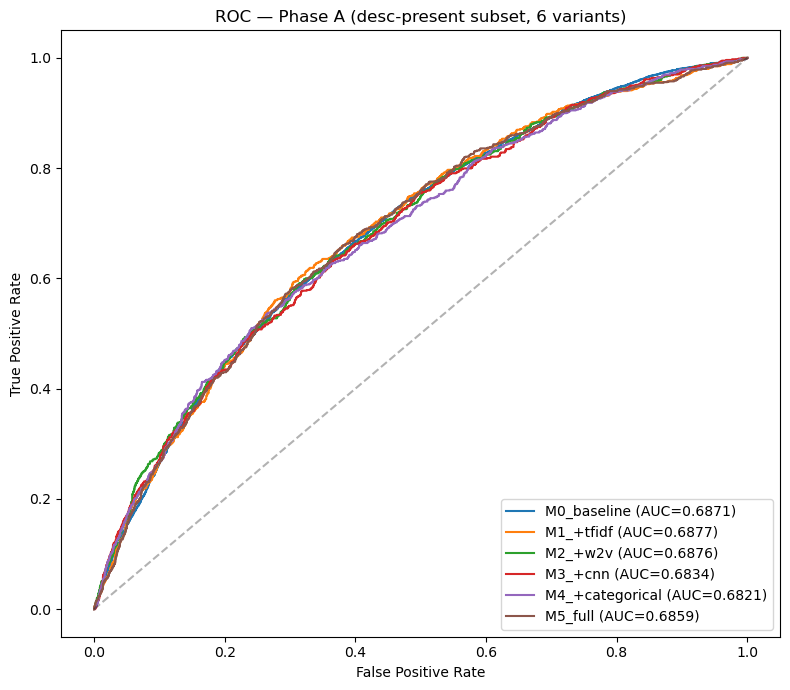

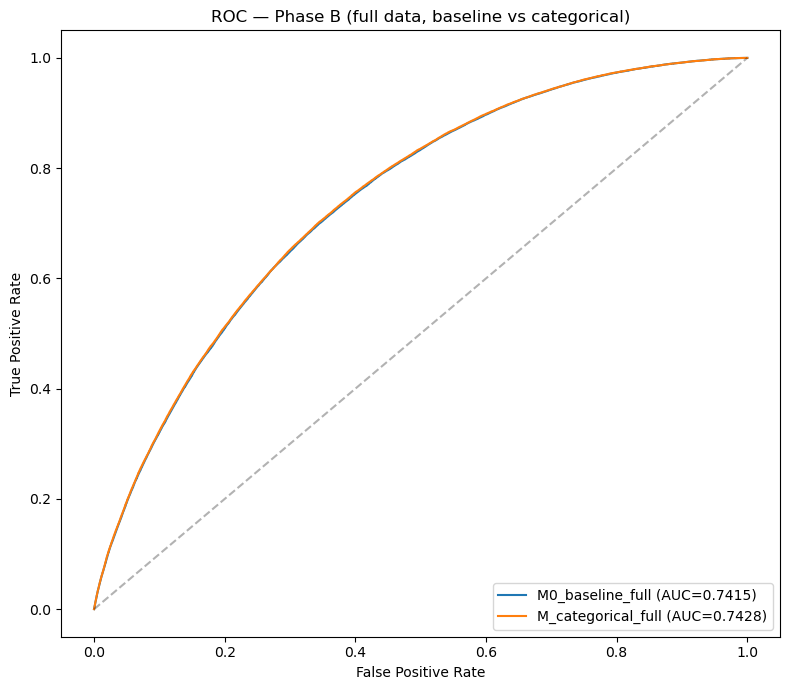

In [19]:
FIG_DIR = "/home/jovyan/work/outputs/figures"

# Phase A — 6 variants overlay
plot_roc_overlay(predictions_subset, results_subset,
                 title="ROC — Phase A (desc-present subset, 6 variants)",
                 out_path=f"{FIG_DIR}/roc_subset.png")

# Phase B — 2 variants overlay
plot_roc_overlay(predictions_full, results_full,
                 title="ROC — Phase B (full data, baseline vs categorical)",
                 out_path=f"{FIG_DIR}/roc_full.png")

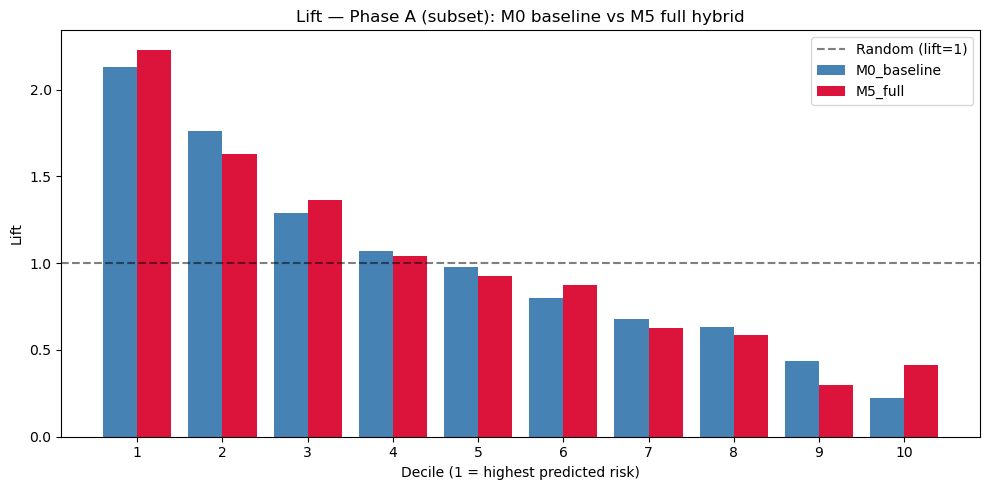

M0_baseline top-decile lift: 2.1336
M5_full top-decile lift: 2.2306


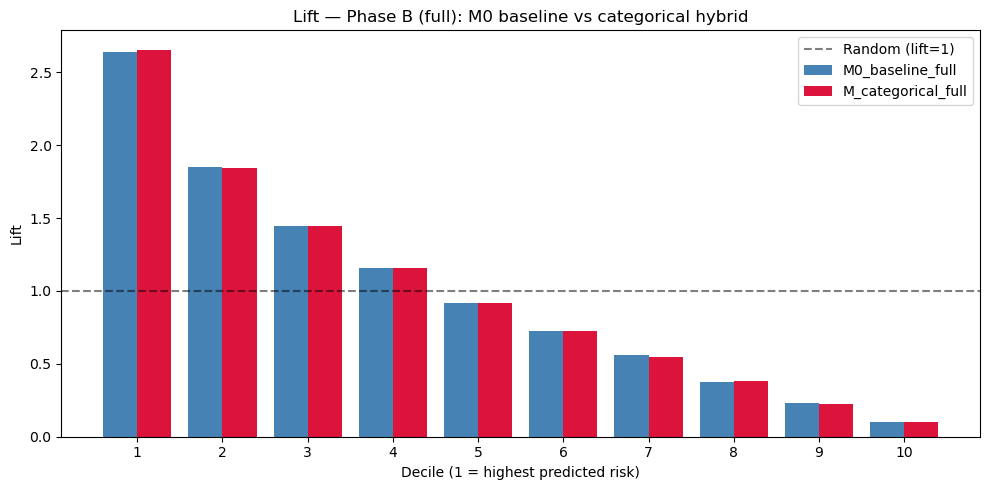

M0_baseline_full top-decile lift: 2.6402
M_categorical_full top-decile lift: 2.6558


(   decile  count  defaults  default_rate      lift  cum_defaults  \
 0       1  45293     15507      0.342371  2.640169         15507   
 1       2  45293     10853      0.239618  1.847795         26360   
 2       3  45293      8474      0.187093  1.442755         34834   
 3       4  45293      6781      0.149714  1.154510         41615   
 4       5  45293      5406      0.119356  0.920407         47021   
 5       6  45293      4275      0.094385  0.727847         51296   
 6       7  45293      3292      0.072682  0.560485         54588   
 7       8  45293      2207      0.048727  0.375756         56795   
 8       9  45293      1339      0.029563  0.227974         58134   
 9      10  45294       601      0.013269  0.102322         58735   
 
    cum_default_rate  
 0          0.264016  
 1          0.448795  
 2          0.593071  
 3          0.708521  
 4          0.800562  
 5          0.873346  
 6          0.929395  
 7          0.966970  
 8          0.989768  
 9       

In [20]:
# Phase A: M0_baseline vs M5_full (full NLP showcase)
plot_lift_comparison(predictions_subset, "M0_baseline", "M5_full",
                     compute_lift_table,
                     title="Lift — Phase A (subset): M0 baseline vs M5 full hybrid",
                     out_path=f"{FIG_DIR}/lift_subset.png")

# Phase B: M0_baseline_full vs M_categorical_full
plot_lift_comparison(predictions_full, "M0_baseline_full", "M_categorical_full",
                     compute_lift_table,
                     title="Lift — Phase B (full): M0 baseline vs categorical hybrid",
                     out_path=f"{FIG_DIR}/lift_full.png")

## Section 7 — Feature Importance (per phase)

Two plots — one per phase's NLP-richest model:
- Phase A: `M5_full` (tfidf + w2v + cnn + title_ohe + emp_ohe). Shows whether NLP features rank in the top coefficients when text is available.
- Phase B: `M_categorical_full` (title_ohe + emp_ohe). Pure categorical signal on full data.

Top 30 features by |coefficient|:
                        feature  coefficient     source
                      cnn_score     3.359172        NLP
           int_rate_(-inf,7_26]     0.644030 structured
                     emp_ohe_18     0.500610        NLP
                     emp_ohe_10     0.492801        NLP
                    grade_F|G|E    -0.430326 structured
                w2v_features_39     0.422336        NLP
                grade_A|MISSING     0.398085 structured
                   title_ohe_10     0.366412        NLP
           int_rate_(7_26,7_99]     0.340311 structured
                     emp_ohe_17     0.324681        NLP
                      emp_ohe_9    -0.317477        NLP
mths_since_issue_d_(32,MISSING]    -0.313761 structured
                w2v_features_32    -0.312572        NLP
   total_rev_hi_lim_(80100,inf]     0.293684 structured
                        grade_D    -0.285393 structured
                      emp_ohe_7     0.264369        NLP
     annual_in

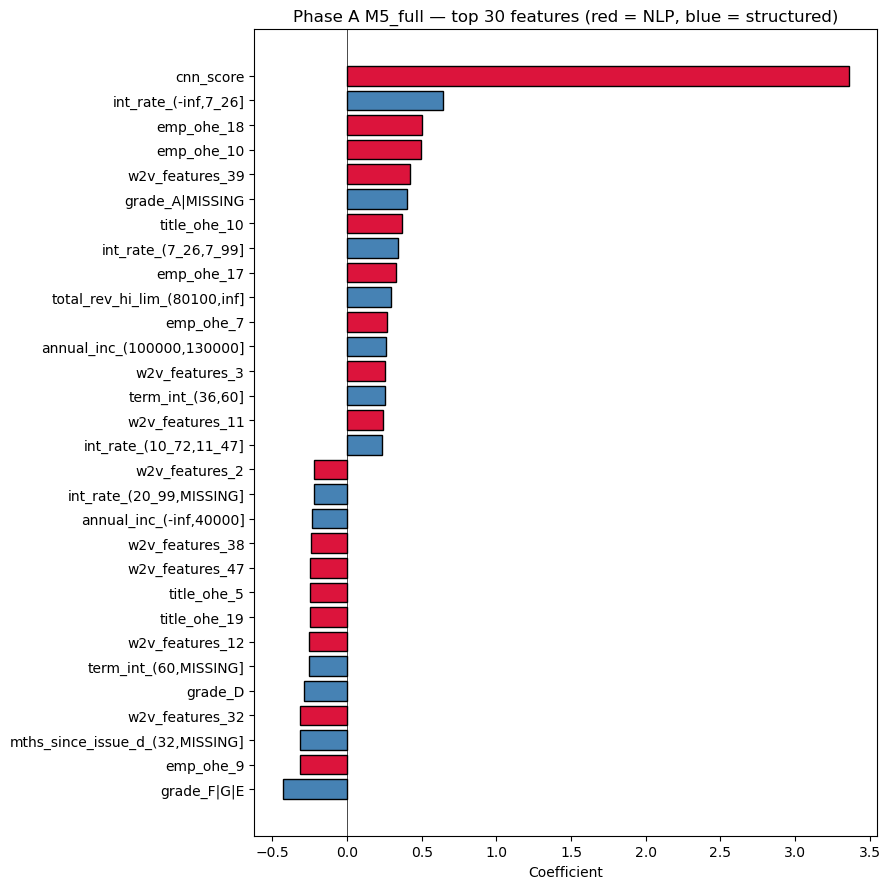

Top 30 features by |coefficient|:
                                feature  coefficient     source
           mths_since_issue_d_(-inf,12]     1.084179 structured
                   int_rate_(-inf,7_26]     0.576504 structured
                            grade_F|G|E    -0.546416 structured
                        grade_A|MISSING     0.491806 structured
                           title_ohe_13     0.414078        NLP
        mths_since_issue_d_(32,MISSING]    -0.375950 structured
               int_rate_(20_99,MISSING]    -0.367672 structured
                           title_ohe_16     0.361044        NLP
             mths_since_issue_d_(27,32]    -0.353352 structured
                             emp_ohe_15     0.313918        NLP
                                grade_D    -0.313726 structured
                           title_ohe_15     0.308713        NLP
                             emp_ohe_13    -0.307270        NLP
                           title_ohe_17     0.277183        NLP
      

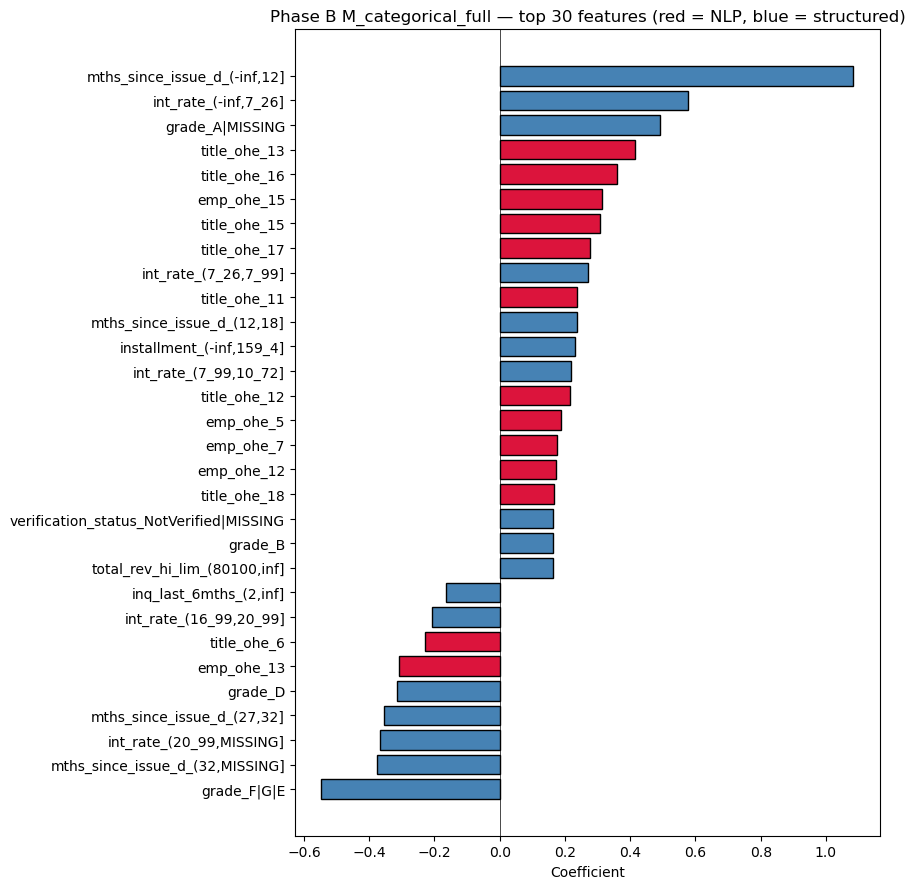

,feature,coefficient,abs_coef,source
0,"mths_since_issue_d_(32,MISSING]",-0.375950,0.375950,structured
1,"mths_since_issue_d_(-inf,12]",1.084179,1.084179,structured
2,grade_A|MISSING,0.491806,0.491806,structured
3,grade_F|G|E,-0.546416,0.546416,structured
4,"term_int_(36,60]",0.073056,0.073056,structured
...,...,...,...,...
94,emp_ohe_14,-0.008764,0.008764,NLP
95,emp_ohe_15,0.313918,0.313918,NLP
96,emp_ohe_16,0.050248,0.050248,NLP
97,emp_ohe_17,0.023822,0.023822,NLP


In [21]:
# Phase A — M5_full feature importance
m5_nlp_cols = variants_subset["M5_full"]
m5_feat_names = extract_feature_names_for_pipeline(
    models_subset["M5_full"], structured_cols, m5_nlp_cols)
plot_feature_importance(
    models_subset["M5_full"], m5_feat_names, top_k=30,
    title="Phase A M5_full — top 30 features (red = NLP, blue = structured)",
    out_path=f"{FIG_DIR}/feature_importance_subset_M5.png")

# Phase B — M_categorical_full feature importance
cat_nlp_cols = variants_full["M_categorical_full"]
cat_feat_names = extract_feature_names_for_pipeline(
    models_full["M_categorical_full"], structured_cols, cat_nlp_cols)
plot_feature_importance(
    models_full["M_categorical_full"], cat_feat_names, top_k=30,
    title="Phase B M_categorical_full — top 30 features (red = NLP, blue = structured)",
    out_path=f"{FIG_DIR}/feature_importance_full_categorical.png")

## Section 8 — LGD & EAD Models (Beta-GLM + LinearRegression)

Targets need raw `funded_amnt` and `total_rec_prncp` from `accepted_general_prep_*.parquet` (not in the WoE-binned features). Models follow teammate's approach:
- **LGD**: Tweedie GLM (var_power=1.5) approximating Beta regression, fit on defaulted loans only
- **EAD**: LinearRegression with CCF (Credit Conversion Factor) target, fit on all loans

MLlib has no Beta/Tweedie GLM, so we use `statsmodels` here (deviation noted in report).

In [22]:
# Load raw fields needed for LGD / EAD targets
raw_train = (spark.read.parquet("/home/jovyan/work/data/parquet/accepted_general_prep_train.parquet")
                  .select("id", "funded_amnt", "total_rec_prncp"))
raw_test  = (spark.read.parquet("/home/jovyan/work/data/parquet/accepted_general_prep_test.parquet")
                  .select("id", "funded_amnt", "total_rec_prncp"))

# Compute LGD = 1 - (total_rec_prncp / funded_amnt), clamp to [0.001, 0.999]
# Compute EAD = funded_amnt * CCF where CCF = total_rec_prncp / funded_amnt (clamped to [0,1])
def add_lgd_ead(df):
    return (df.withColumn("recovery_rate",
                          F.when(F.col("funded_amnt") > 0,
                                 F.col("total_rec_prncp") / F.col("funded_amnt")).otherwise(0.0))
              .withColumn("ccf", F.greatest(F.lit(0.0), F.least(F.lit(1.0), F.col("recovery_rate"))))
              .withColumn("lgd", F.greatest(F.lit(0.001),
                                            F.least(F.lit(0.999), F.lit(1.0) - F.col("recovery_rate"))))
              .withColumn("ead", F.col("funded_amnt") * F.col("ccf")))

raw_train = add_lgd_ead(raw_train)
raw_test  = add_lgd_ead(raw_test)
raw_train.select("id", "funded_amnt", "total_rec_prncp", "lgd", "ead").show(5)

+---------+-----------+---------------+------------------+-------+
|       id|funded_amnt|total_rec_prncp|               lgd|    ead|
+---------+-----------+---------------+------------------+-------+
|100044617|     4800.0|        2282.06|0.5245708333333333|2282.06|
|100065804|     6000.0|         582.29|0.9029516666666667| 582.29|
| 10024615|    21000.0|        21000.0|             0.001|21000.0|
| 10074757|    28000.0|        28000.0|             0.001|28000.0|
| 10090955|     4025.0|         4025.0|             0.001| 4025.0|
+---------+-----------+---------------+------------------+-------+
only showing top 5 rows



In [23]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import GeneralizedLinearRegression

# LGD: fit on defaulted loans only (good_bad=0) using Spark ML (no wide toPandas)
lgd_train_sdf = (struct_train
                 .filter(F.col("good_bad") == 0)
                 .select("id", *structured_cols)
                 .join(raw_train.select("id", "lgd"), on="id", how="inner")
                 .fillna(0))

n_lgd_train = lgd_train_sdf.count()
mean_lgd_train = lgd_train_sdf.agg(F.mean("lgd").alias("mean_lgd")).first()["mean_lgd"]
print(f"LGD train: {n_lgd_train:,} defaulted loans, mean LGD={mean_lgd_train:.4f}")

lgd_test_sdf = (struct_test
                .select("id", *structured_cols)
                .join(raw_test.select("id", "lgd"), on="id", how="inner")
                .fillna(0))

lgd_assembler = VectorAssembler(
    inputCols=structured_cols,
    outputCol="features",
    handleInvalid="skip"
)

# Tweedie GLM with log link (linkPower=0.0)
lgd_glm = GeneralizedLinearRegression(
    featuresCol="features",
    labelCol="lgd",
    family="tweedie",
    variancePower=1.5,
    linkPower=0.0,
    maxIter=50,
    regParam=0.0
)

lgd_model = Pipeline(stages=[lgd_assembler, lgd_glm]).fit(lgd_train_sdf)
print("LGD GLM fit complete.")

lgd_pred_sdf = (lgd_model.transform(lgd_test_sdf)
                .withColumn("lgd_pred", F.col("prediction").cast("double"))
                .withColumn("lgd_pred", F.when(F.col("lgd_pred") < 0.001, 0.001)
                                        .when(F.col("lgd_pred") > 0.999, 0.999)
                                        .otherwise(F.col("lgd_pred")))
                .select("id", "lgd_pred"))

lgd_stats = lgd_pred_sdf.agg(
    F.mean("lgd_pred").alias("mean_pred"),
    F.min("lgd_pred").alias("min_pred"),
    F.max("lgd_pred").alias("max_pred")
).first()
print(f"LGD test predictions: mean={lgd_stats['mean_pred']:.4f}, min={lgd_stats['min_pred']:.4f}, max={lgd_stats['max_pred']:.4f}")

# Keep downstream compute_el_table unchanged (expects pandas with id + lgd_pred)
lgd_test_pdf = lgd_pred_sdf.toPandas()



LGD train: 232,092 defaulted loans, mean LGD=0.6934
LGD GLM fit complete.
LGD test predictions: mean=0.6995, min=0.4874, max=0.9990


In [24]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import LinearRegression as SparkLinearRegression

# EAD: fit on all train borrowers using Spark ML (no wide toPandas)
ead_train_sdf = (struct_train
                 .select("id", *structured_cols)
                 .join(raw_train.select("id", "ead"), on="id", how="inner")
                 .fillna(0))

ead_test_sdf = (struct_test
                .select("id", *structured_cols)
                .join(raw_test.select("id", "ead"), on="id", how="inner")
                .fillna(0))

ead_assembler = VectorAssembler(
    inputCols=structured_cols,
    outputCol="features",
    handleInvalid="skip"
)

ead_lr = SparkLinearRegression(
    featuresCol="features",
    labelCol="ead",
    maxIter=100,
    regParam=0.0,
    elasticNetParam=0.0
)

ead_model = Pipeline(stages=[ead_assembler, ead_lr]).fit(ead_train_sdf)
ead_lr_model = ead_model.stages[-1]
if hasattr(ead_lr_model, "summary"):
    print(f"EAD LinearRegression R^2 (train): {ead_lr_model.summary.r2:.4f}")

ead_pred_sdf = (ead_model.transform(ead_test_sdf)
                .withColumn("ead_pred", F.greatest(F.col("prediction").cast("double"), F.lit(0.0)))
                .select("id", "ead_pred"))

ead_stats = ead_pred_sdf.agg(
    F.mean("ead_pred").alias("mean_pred"),
    F.min("ead_pred").alias("min_pred"),
    F.max("ead_pred").alias("max_pred")
).first()
print(f"EAD test predictions: mean=${ead_stats['mean_pred']:.2f}, min=${ead_stats['min_pred']:.2f}, max=${ead_stats['max_pred']:.2f}")

# Keep downstream compute_el_table unchanged (expects pandas with id + ead_pred)
ead_test_pdf = ead_pred_sdf.toPandas()



EAD LinearRegression R^2 (train): 0.4372
EAD test predictions: mean=$9667.22, min=$0.00, max=$23170.89


In [25]:
# LGD/EAD were fit on full train and predicted on full test → covers all
# Phase B ids and (a superset of) Phase A test ids. inner-merge in compute_el_table
# auto-restricts each phase to its own test ids.

# Phase A
el_subset_df = compute_el_table(
    predictions_subset,
    baseline_name="M0_baseline", hybrid_name="M5_full",
    lgd_pdf=lgd_test_pdf, ead_pdf=ead_test_pdf,
    out_path="/home/jovyan/work/outputs/tables/expected_loss_subset.csv")

print()

# Phase B
el_full_df = compute_el_table(
    predictions_full,
    baseline_name="M0_baseline_full", hybrid_name="M_categorical_full",
    lgd_pdf=lgd_test_pdf, ead_pdf=ead_test_pdf,
    out_path="/home/jovyan/work/outputs/tables/expected_loss_full.csv")

=== EL summary (M0_baseline vs M5_full) ===
Loans: 5,080
Total EL — baseline: $6,033,159.82
Total EL — hybrid:   $6,032,042.18
Mean EL/loan — baseline: $1187.63
Mean EL/loan — hybrid:   $1187.41
Mean delta: $-0.22

Saved /home/jovyan/work/outputs/tables/expected_loss_subset.csv

=== EL summary (M0_baseline_full vs M_categorical_full) ===
Loans: 452,931
Total EL — baseline: $428,704,435.05
Total EL — hybrid:   $428,671,885.51
Mean EL/loan — baseline: $946.51
Mean EL/loan — hybrid:   $946.44
Mean delta: $-0.07

Saved /home/jovyan/work/outputs/tables/expected_loss_full.csv


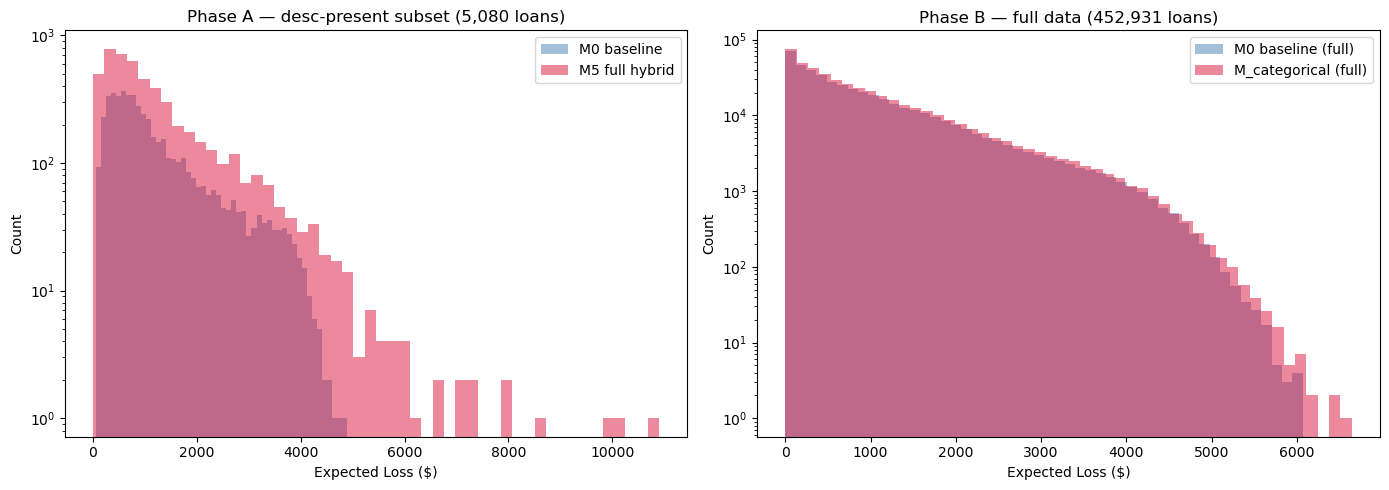

In [26]:
# EL distribution per phase (log-scale because EL is right-skewed)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(el_subset_df["EL_baseline"], bins=50, alpha=0.5,
             label="M0 baseline", color="steelblue")
axes[0].hist(el_subset_df["EL_hybrid"],   bins=50, alpha=0.5,
             label="M5 full hybrid", color="crimson")
axes[0].set_xlabel("Expected Loss ($)")
axes[0].set_ylabel("Count")
axes[0].set_yscale("log")
axes[0].set_title(f"Phase A — desc-present subset ({len(el_subset_df):,} loans)")
axes[0].legend()

axes[1].hist(el_full_df["EL_baseline"], bins=50, alpha=0.5,
             label="M0 baseline (full)", color="steelblue")
axes[1].hist(el_full_df["EL_hybrid"],   bins=50, alpha=0.5,
             label="M_categorical (full)", color="crimson")
axes[1].set_xlabel("Expected Loss ($)")
axes[1].set_ylabel("Count")
axes[1].set_yscale("log")
axes[1].set_title(f"Phase B — full data ({len(el_full_df):,} loans)")
axes[1].legend()

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/el_comparison.png", dpi=120)
plt.show()


## Done

Outputs created:

**Tables**
- `outputs/tables/hybrid_model_comparison_subset.csv` — Phase A (6 variants) AUC/Gini/KS
- `outputs/tables/hybrid_model_comparison_full.csv` — Phase B (2 variants) AUC/Gini/KS
- `outputs/tables/expected_loss_subset.csv` — Phase A per-loan EL (M0 vs M5_full)
- `outputs/tables/expected_loss_full.csv` — Phase B per-loan EL (M0 vs M_categorical_full)

**Figures**
- `outputs/figures/roc_subset.png`, `roc_full.png`
- `outputs/figures/lift_subset.png`, `lift_full.png`
- `outputs/figures/feature_importance_subset_M5.png`
- `outputs/figures/feature_importance_full_categorical.png`
- `outputs/figures/el_comparison.png` — Phase A vs Phase B EL distributions side-by-side

**Models**
- `outputs/models/hybrid_pd_M5_subset/` — Phase A M5_full (NLP showcase)
- `outputs/models/hybrid_pd_categorical_full/` — Phase B production categorical model